Analyzing the SNOTEL site at Reynolds Creek (#2029). Is there increasing melt in winter? Decreasing final SWE at initiation of melt? Earlier melt initiation?

In [20]:
import os
import pandas as pd
import numpy as np

files = [f for f in os.listdir() if f.endswith(".csv")]

dfs = []

for file in files:
    df_temp = pd.read_csv(file)
    df_temp["Date"] = pd.to_datetime(df_temp["Date"])

    year = file.split("=")[-1].replace(".csv", "")
    df_temp["WaterYear"] = int(year)

    dfs.append(df_temp)

df = pd.concat(dfs, axis=0)
df = df.sort_values("Date").set_index("Date")

In [21]:
print(files[:5])
print(df.head())
print(df.tail())
print(df.columns)

['2029_STAND_WATERYEAR=2002.csv', '2029_STAND_WATERYEAR=2005.csv', '2029_STAND_WATERYEAR=2006.csv', '2029_STAND_WATERYEAR=2007.csv', '2029_STAND_WATERYEAR=2008.csv']
           Site Id  WTEQ.I-1 (in)   PREC.I-1 (in)   TOBS.I-1 (degC)   \
Date                                                                   
2001-10-01    2029             0.0             0.0             -99.9   
2001-10-02    2029             0.0             0.0             -99.9   
2001-10-03    2029             0.0             0.0             -99.9   
2001-10-04    2029             0.0             0.0             -99.9   
2001-10-05    2029             0.0             0.0             -99.9   

            TMAX.D-1 (degC)   TMIN.D-1 (degC)   TAVG.D-1 (degC)   \
Date                                                               
2001-10-01              21.9               7.7              15.1   
2001-10-02              26.8              13.1              20.7   
2001-10-03              23.4              12.5           

In [22]:
#Clean up the bullsh**

df=df.drop(columns=["Site Id", "TOBS.I-1 (degC) ", "TMAX.D-1 (degC) ", "TMIN.D-1 (degC) ", "TAVG.D-1 (degC) ", "SNWD.I-1 (in) "])

print(df.columns)
    

Index(['WTEQ.I-1 (in) ', 'PREC.I-1 (in) ', 'WaterYear'], dtype='object')


In [23]:
#Rename the garbage

df = df.rename(columns={"WTEQ.I-1 (in) ": "SWE", "PREC.I-1 (in) ": "Precip", "WaterYear": "WY"})
print(df.columns)


Index(['SWE', 'Precip', 'WY'], dtype='object')


In [24]:
#Replace missing values with NaN

df=df.replace(-99.9, np.nan)

In [25]:
df["SWE"]=df["SWE"]*25.4
df["Precip"]=df["Precip"]*25.4

In [26]:
df["D"]=df.index.dayofyear.astype("Int64")
print(df.head())

            SWE  Precip    WY    D
Date                              
2001-10-01  0.0     0.0  2002  274
2001-10-02  0.0     0.0  2002  275
2001-10-03  0.0     0.0  2002  276
2001-10-04  0.0     0.0  2002  277
2001-10-05  0.0     0.0  2002  278


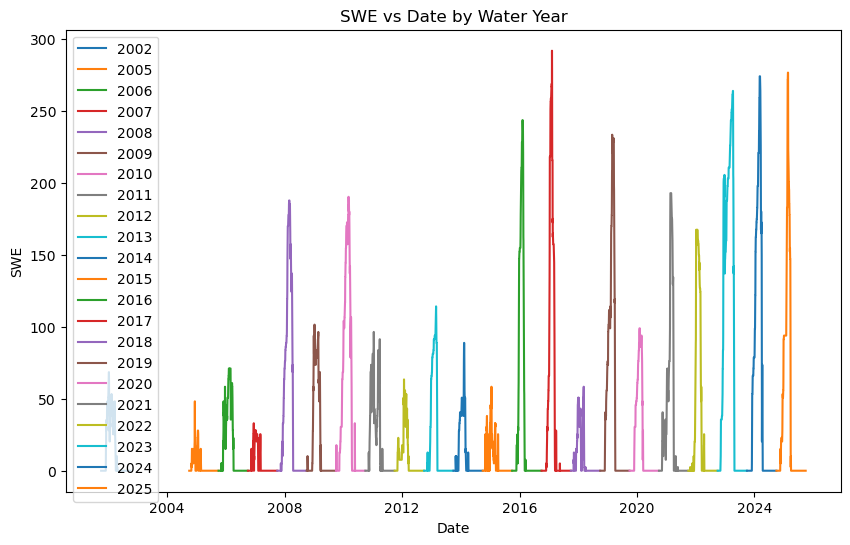

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

for year, sub in df.groupby("WY"):
    ax.plot(sub.index, sub["SWE"], label=year)

ax.set_xlabel("Date")
ax.set_ylabel("SWE")
ax.set_title("SWE vs Date by Water Year")

ax.legend()
plt.show()

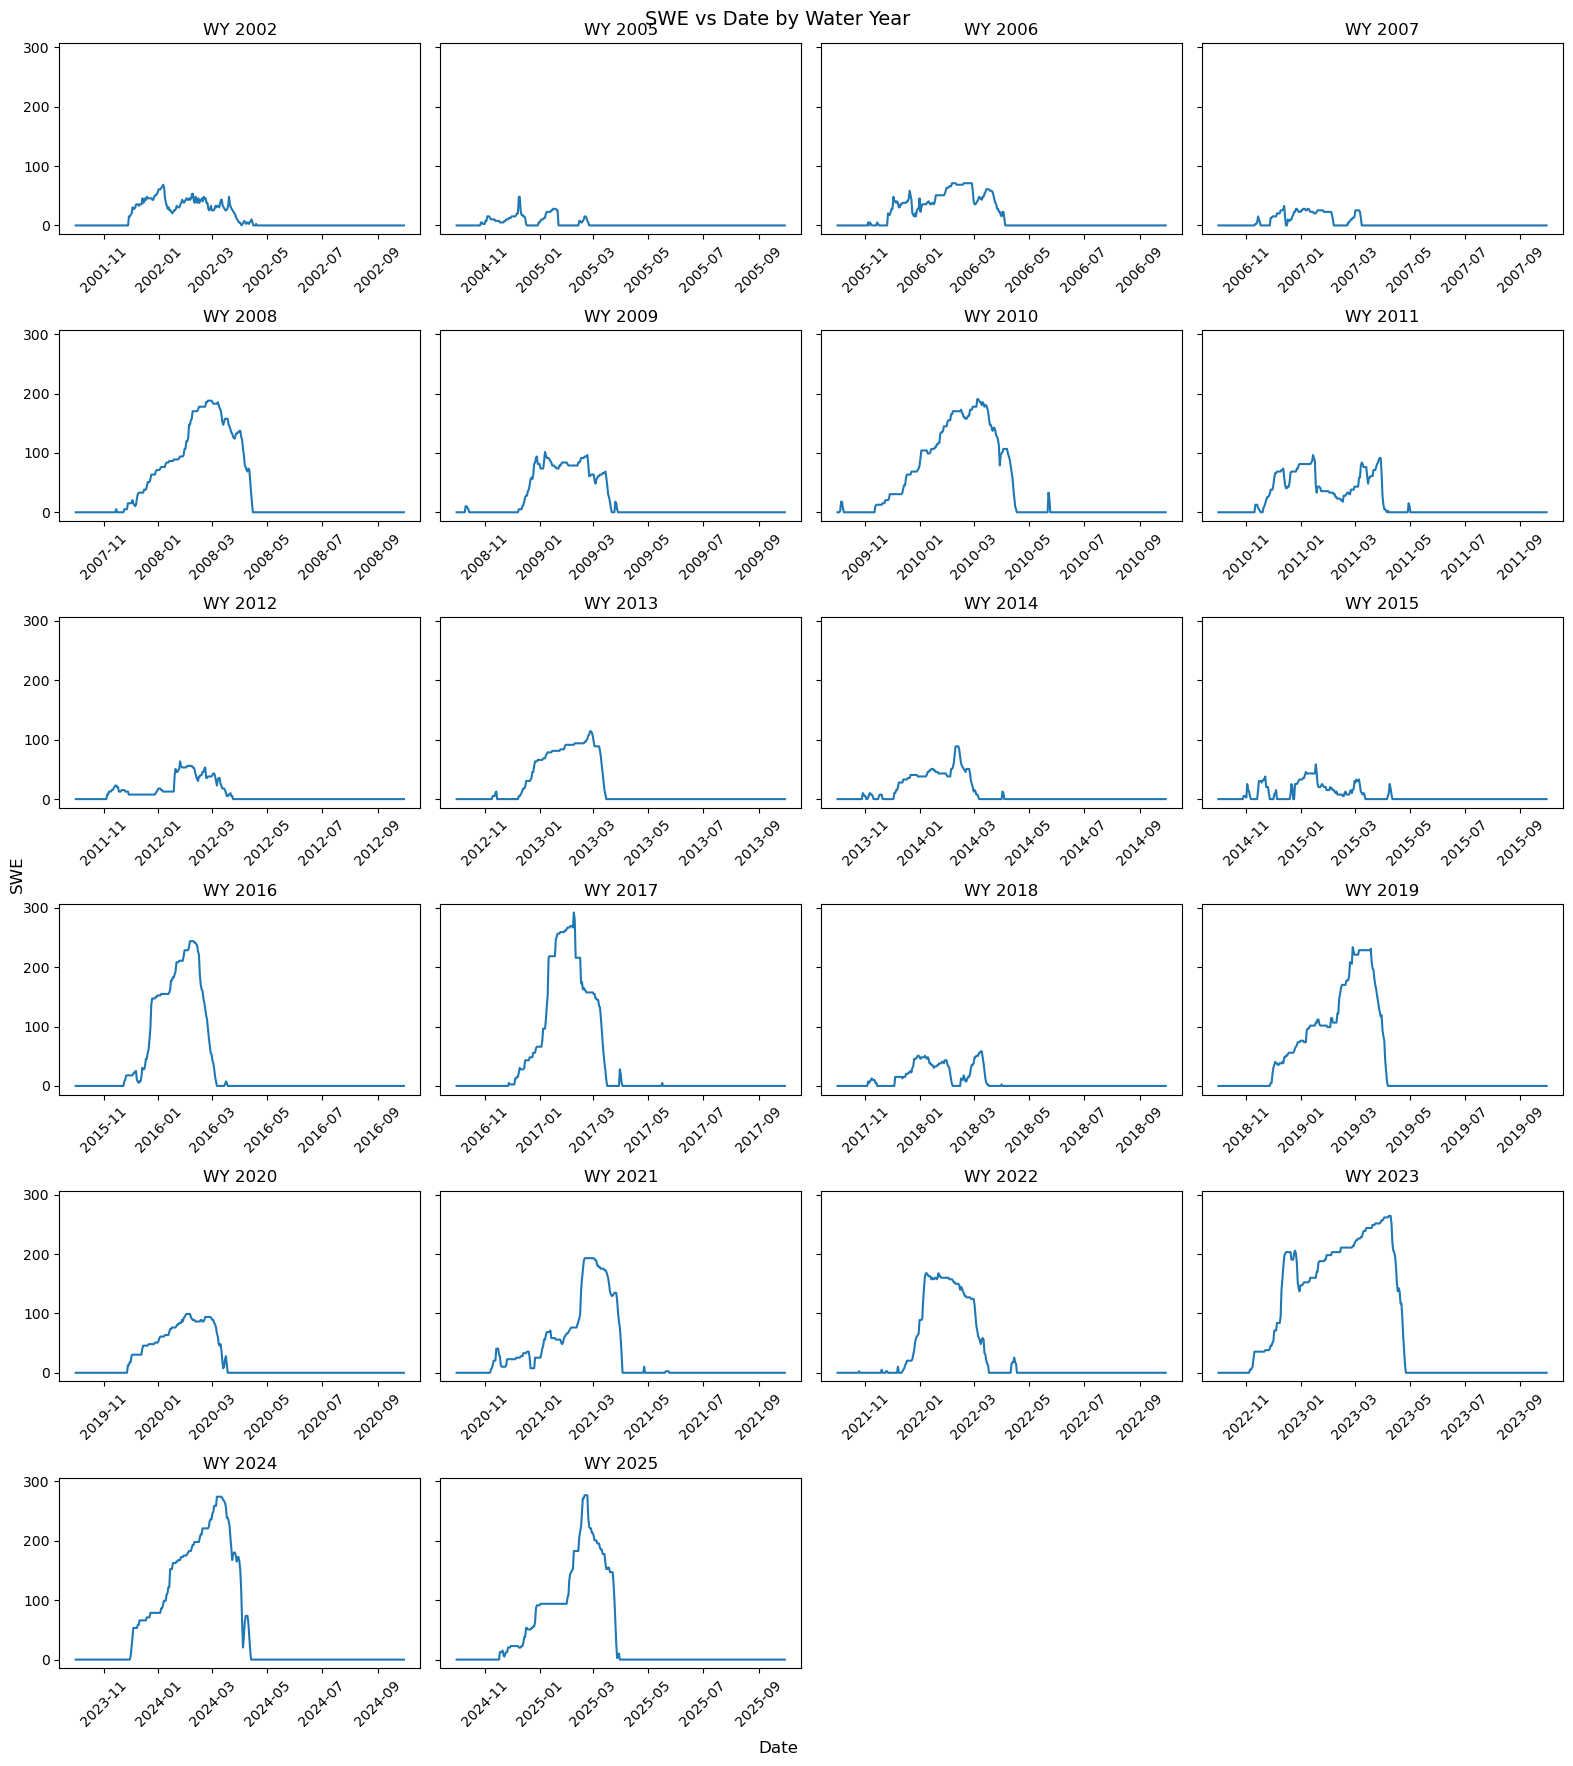

In [28]:
import matplotlib.pyplot as plt
import math

years = sorted(df["WY"].unique())

n = len(years)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3*nrows), sharey=True)
axes = axes.flatten()

for i, year in enumerate(years):
    sub = df[df["WY"] == year]
    
    axes[i].plot(sub.index, sub["SWE"])
    axes[i].set_title(f"WY {year}")
    axes[i].tick_params(axis="x", rotation=45)

# Turn off any extra empty panels
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.supxlabel("Date")
fig.supylabel("SWE")
fig.suptitle("SWE vs Date by Water Year", fontsize=14)

plt.tight_layout()
plt.show()